In [157]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import plot_tree

In [158]:
PATH = "asteroid.csv"

In [159]:
df = pd.read_csv(PATH)

C:\Users\ponts\AppData\Local\Temp\ipykernel_15272\3476328945.py:1: DtypeWarning: Columns (0: pdes, 1: name, 2: prefix) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH)


In [160]:
df.head()

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [161]:
print(df.shape)

(958524, 45)


In [162]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
id                     0
spkid                  0
full_name              0
pdes                   0
name              936460
prefix            958506
neo                    4
pha                19921
H                   6263
diameter          822315
albedo            823421
diameter_sigma    822443
orbit_id               0
epoch                  0
epoch_mjd              0
epoch_cal              0
equinox                0
e                      0
a                      0
q                      0
i                      0
om                     0
w                      0
ma                     1
ad                     4
n                      0
tp                     0
tp_cal                 0
per                    4
per_y                  1
moid               19921
moid_ld              127
sigma_e            19922
sigma_a            19922
sigma_q            19922
sigma_i            19922
sigma_om           19922
sigma_w            19922
sigma_ma           

In [163]:
print("Duplicate rows in the dataset:", df.duplicated().sum())

Duplicate rows in the dataset: 0


In [164]:
# Remove rows with ANY NaN values
df_no_nulls = df.dropna()

In [165]:
print("Dataset shape after removing rows with NaN values:", df_no_nulls.isnull().sum())
print("Dataset shape after removing rows with NaN values:", df_no_nulls.shape)

Dataset shape after removing rows with NaN values: id                0
spkid             0
full_name         0
pdes              0
name              0
prefix            0
neo               0
pha               0
H                 0
diameter          0
albedo            0
diameter_sigma    0
orbit_id          0
epoch             0
epoch_mjd         0
epoch_cal         0
equinox           0
e                 0
a                 0
q                 0
i                 0
om                0
w                 0
ma                0
ad                0
n                 0
tp                0
tp_cal            0
per               0
per_y             0
moid              0
moid_ld           0
sigma_e           0
sigma_a           0
sigma_q           0
sigma_i           0
sigma_om          0
sigma_w           0
sigma_ma          0
sigma_ad          0
sigma_n           0
sigma_tp          0
sigma_per         0
class             0
rms               0
dtype: int64
Dataset shape after removing rows wi

In [166]:
df_no_nulls.head()

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms


- Dropping rows by searching for null rows removes every entry

- Since my main focus on the diameter of Asteroids, missing asteroid data will only hinder my research
    - So i will remove rows with missing diameters

In [167]:
df_no_diameter_nulls = df.dropna(subset=['diameter'])

In [168]:
df_no_diameter_nulls.head()

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [169]:
print("Dataset shape after removing rows with NaN values:", df_no_diameter_nulls.isnull().sum())

Dataset shape after removing rows with NaN values: id                     0
spkid                  0
full_name              0
pdes                   0
name              121047
prefix            136209
neo                    0
pha                    0
H                   4164
diameter               0
albedo              1109
diameter_sigma       128
orbit_id               0
epoch                  0
epoch_mjd              0
epoch_cal              0
equinox                0
e                      0
a                      0
q                      0
i                      0
om                     0
w                      0
ma                     0
ad                     0
n                      0
tp                     0
tp_cal                 0
per                    0
per_y                  0
moid                   0
moid_ld                0
sigma_e                0
sigma_a                0
sigma_q                0
sigma_i                0
sigma_om               0
sigma_w                0

In [170]:
### Drop unnecessary columns

columns_to_drop = [
    "spkid", "fullname", "pdes", "name", "prefix",
    "diameter_sigma",
    "epoch_mjd", "epoch_cal",
    "orbit_id"
    "tp_cal",
    "per_y",
    "moid_ld"
]

cols_to_drop = [c for c in columns_to_drop if c in df_no_diameter_nulls.columns]
df_no_diameter_nulls = df_no_diameter_nulls.drop(columns=cols_to_drop)

In [171]:
df_no_diameter_nulls.head()

,id,full_name,neo,pha,H,diameter,albedo,orbit_id,epoch,equinox,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,1 Ceres,N,N,3.40,939.400,0.0900,JPL 47,2458600.5,J2000,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2 Pallas,N,N,4.20,545.000,0.1010,JPL 37,2459000.5,J2000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,3 Juno,N,N,5.33,246.596,0.2140,JPL 112,2459000.5,J2000,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,4 Vesta,N,N,3.00,525.400,0.4228,JPL 35,2458600.5,J2000,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,5 Astraea,N,N,6.90,106.699,0.2740,JPL 114,2459000.5,J2000,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


- Dataframe is now free of Null diameters.

### 2. Categorical Encoding

In [172]:
### Set ID as index
df = df_no_diameter_nulls.set_index('id')

y_diameter = df['diameter']

In [173]:
y_diameter.head()

id
a0000001    939.400
a0000002    545.000
a0000003    246.596
a0000004    525.400
a0000005    106.699
Name: diameter, dtype: float64

### Label encoding vs One-Hot Encoding

1. Label encoding creates an order to the categories

2. One-Hot Encoder simply categorises the data with no ranking/order

In [174]:
### Testing which columns to encode

# Check which columns are categorical and need encoding
columns = ['neo', 'pha', 'class']

for col in columns:
    print("=" * 40)
    print("Column: ", col)
    print(df_no_diameter_nulls[col].value_counts())


Column:  neo
neo
N    135360
Y       849
Name: count, dtype: int64
Column:  pha
pha
N    135988
Y       221
Name: count, dtype: int64
Column:  class
class
MBA    124971
OMB      7521
TJN      1873
IMB       566
APO       486
MCA       358
AMO       268
ATE        95
CEN        51
TNO        12
AST         8
Name: count, dtype: int64


In [175]:
def get_unique_values(df, column):
    unique_values = df[column].unique()
    #print(f"Unique values in column '{column}': {unique_values}")
    return unique_values

for col in columns:
    print(get_unique_values(df_no_diameter_nulls, col))

<StringArray>
['N', 'Y']
Length: 2, dtype: str
<StringArray>
['N', 'Y']
Length: 2, dtype: str
<StringArray>
['MBA', 'OMB', 'MCA', 'AMO', 'IMB', 'TJN', 'CEN', 'APO', 'ATE', 'AST', 'TNO']
Length: 11, dtype: str


In [176]:
def encode_categorical_columns(df, columns):
    encoded_df = df.copy()
    binary_cols = []
    one_hot_cols = []

    for col in columns:
        if col not in encoded_df.columns:
            continue

        n_unique = encoded_df[col].nunique(dropna=True)

        if n_unique == 2:
            le = LabelEncoder()
            encoded_df[col] = le.fit_transform(encoded_df[col])
            binary_cols.append(col)
        elif n_unique > 2:
            one_hot_cols.append(col)

    if one_hot_cols:
        encoded_df = pd.get_dummies(encoded_df, columns=one_hot_cols, drop_first=True)

    return encoded_df, binary_cols, one_hot_cols

encoded_df, binary_cols, one_hot_cols = encode_categorical_columns(df_no_diameter_nulls, columns)
print("Label-encoded columns:", binary_cols)
print("One-hot encoded columns:", one_hot_cols)
encoded_df.head()

Label-encoded columns: ['neo', 'pha']
One-hot encoded columns: ['class']


,id,full_name,neo,pha,H,diameter,albedo,orbit_id,epoch,equinox,...,class_APO,class_AST,class_ATE,class_CEN,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,a0000001,1 Ceres,0,0,3.40,939.400,0.0900,JPL 47,2458600.5,J2000,...,False,False,False,False,False,True,False,False,False,False
1,a0000002,2 Pallas,0,0,4.20,545.000,0.1010,JPL 37,2459000.5,J2000,...,False,False,False,False,False,True,False,False,False,False
2,a0000003,3 Juno,0,0,5.33,246.596,0.2140,JPL 112,2459000.5,J2000,...,False,False,False,False,False,True,False,False,False,False
3,a0000004,4 Vesta,0,0,3.00,525.400,0.4228,JPL 35,2458600.5,J2000,...,False,False,False,False,False,True,False,False,False,False
4,a0000005,5 Astraea,0,0,6.90,106.699,0.2740,JPL 114,2459000.5,J2000,...,False,False,False,False,False,True,False,False,False,False


### 3. Feature Selection

- Feature selection using decision trees involves identifying the most important features in a dataset based on their contribution to the decision tree's performance.

- Feature selection involves choosing a subset of important features for building a model. 
    - It aims to enhance model performance by reducing overfitting, improving interpretability, and cutting computational complexity.

#### Decision Trees

- Decision trees are a popular machine learning algorithm used for both classification and regression tasks.
- They model decisions based on the features of the data and their outcomes.

 - Decision trees select the 'best' feature for splitting at each node based on information gain.

### Note to self:

- Read the question, read the online geek for geeks source and their code, basically we need to use their method

- Create the model first and then do feature selection.

- Its so simple, i was looking at it differently all along. We are modelling the diameter of rock, using every other feature in the table.

### 4. Splitting the data

-  Splitting the dataset into data and test sets

In [177]:
x = encoded_df.drop(columns=['diameter', 'full_name', 'orbit_id', 'equinox'])
y = encoded_df['diameter']

x = x.set_index('id')

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size=0.3)

In [178]:
print("\nTraining set shape:", x_train.shape)
print("Test set shape:", x_test.shape)


Training set shape: (95346, 40)
Test set shape: (40863, 40)


In [179]:
### Scale the data

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [180]:
# Convert back to DataFrame so feature names stay available
X_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
X_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)

#### Note

- We are trying to predict continuous data right

- **DecisionTreeClassifiers** are used to classify data into "Spam" or "Not Spam".

- **DecsionTreeRegressors** are use to predict continuous data.

In [181]:
# # Train a Decision Tree Classifier
# clf = DecisionTreeClassifier(max_depth=16, random_state=8)
# clf.fit(x_train_scaled, y_train)
# y_pred = clf.predict(x_test_scaled)

In [182]:
# =========================================
# 9. Train initial Decision Tree Regressor
# =========================================

In [183]:
regressor = DecisionTreeRegressor(max_depth=4, random_state=42)
regressor.fit(x_train_scaled, y_train)
y_pred = regressor.predict(x_test_scaled)

In [184]:
# Get feature importances
importances = pd.Series(regressor.feature_importances_, index=x_train.columns)
importances = importances.sort_values(ascending=False)

print("\nTop feature importances:")
print(importances.head(10))

# Select features with importance greater than a threshold
threshold = 0.0001  # Adjust as needed
selected_features = x.columns[importances > threshold]

# Use only the selected features
X_train_selected = x_train[selected_features]
X_test_selected = x_test[selected_features]


Top feature importances:
H         0.914398
albedo    0.076880
per       0.008722
pha       0.000000
epoch     0.000000
e         0.000000
a         0.000000
neo       0.000000
q         0.000000
i         0.000000
dtype: float64


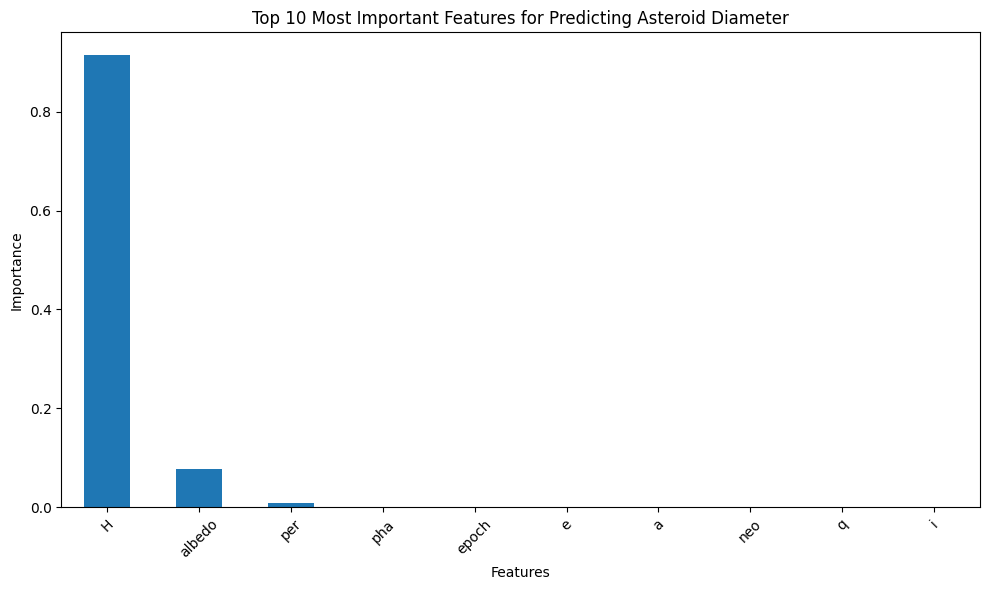

In [185]:
### Plot Selected Features

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Most Important Features for Predicting Asteroid Diameter")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [186]:
# Train a new model using the selected features
regressor_selected = DecisionTreeRegressor(max_depth=16, random_state=8)
regressor_selected.fit(X_train_selected, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",8
,"max_leaf

In [187]:
# # Make predictions on the test set using the model trained with all features
# y_pred_all_features = regressor.predict(x_test_scaled)

# # Calculate the accuracy of the model with all features
# accuracy_all_features = accuracy_score(y_test, y_pred_all_features)
# print(f"Accuracy with all features: {accuracy_all_features}")

# # Make predictions on the test set using the model trained with selected features
# y_pred_selected_features = regressor_selected.predict(X_test_selected)

# # Calculate the accuracy of the model with selected features
# accuracy_selected_features = accuracy_score(y_test, y_pred_selected_features)
# print(f"Accuracy with selected features: {accuracy_selected_features}")

In [188]:
# Correct regression evaluation (use this instead of accuracy_score)
y_pred_all_features = regressor.predict(x_test_scaled)
mae_all = mean_absolute_error(y_test, y_pred_all_features)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all_features))
r2_all = r2_score(y_test, y_pred_all_features)
print(f"All features -> MAE: {mae_all:.4f}, RMSE: {rmse_all:.4f}, R^2: {r2_all:.4f}")

y_pred_selected_features = regressor_selected.predict(X_test_selected)
mae_selected = mean_absolute_error(y_test, y_pred_selected_features)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected_features))
r2_selected = r2_score(y_test, y_pred_selected_features)
print(f"Selected features -> MAE: {mae_selected:.4f}, RMSE: {rmse_selected:.4f}, R^2: {r2_selected:.4f}")

All features -> MAE: 1.4698, RMSE: 3.4150, R^2: 0.8838
Selected features -> MAE: 1.5865, RMSE: 3.8487, R^2: 0.8525


### Plot decision Tree

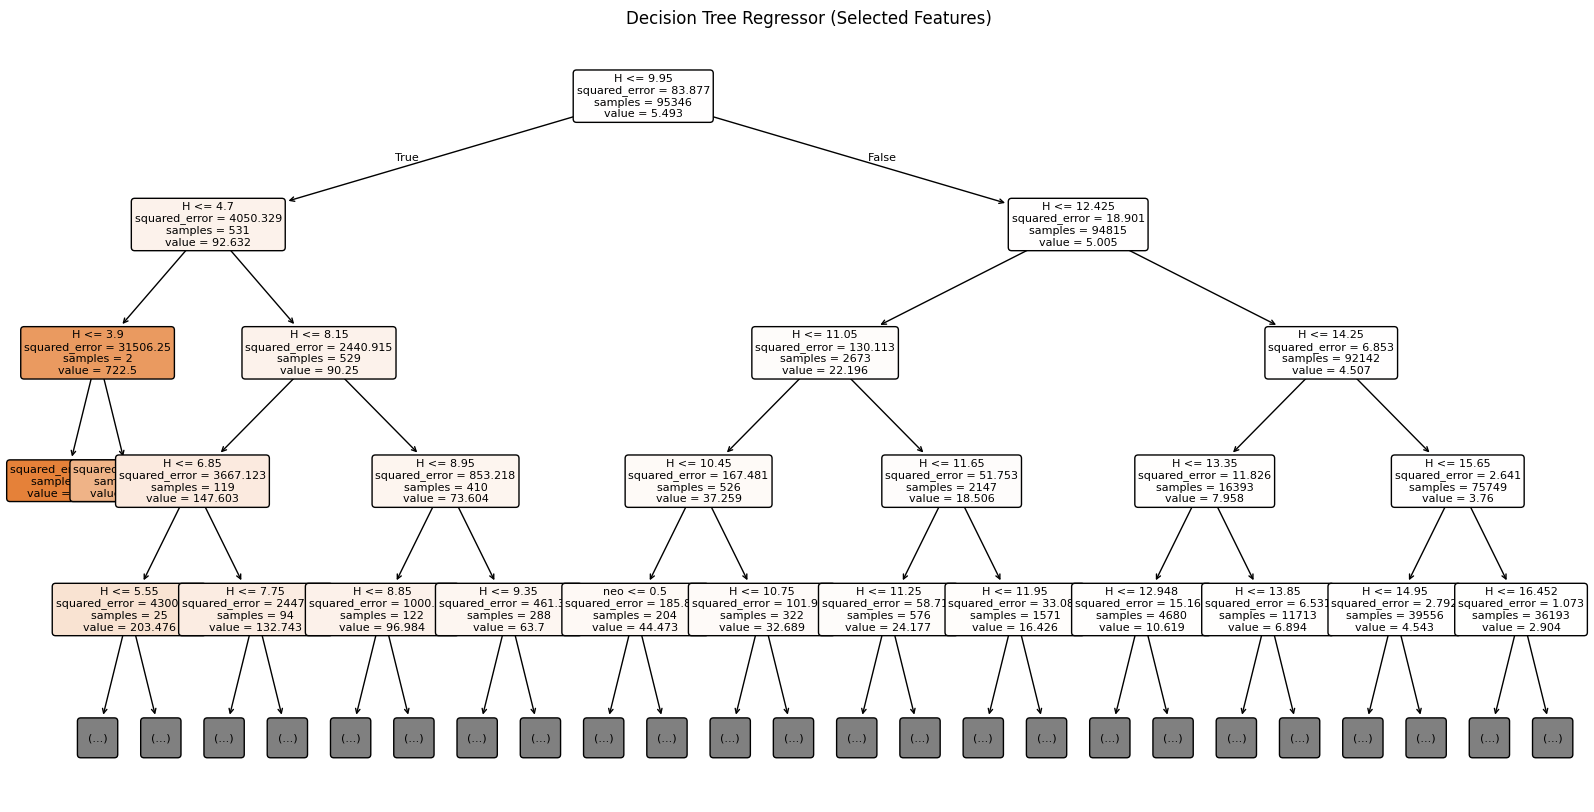

In [189]:
### Plot decision tree

plt.figure(figsize=(20, 10))
plot_tree(
    regressor_selected,
    feature_names=selected_features,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4  # remove this line to show full tree
)
plt.title("Decision Tree Regressor (Selected Features)")
plt.show()